<a href="https://colab.research.google.com/github/anshksonker04/Used-Car-Price-Prediction-Model-/blob/main/cleaned_vehicles_data__ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/vehicles.csv")
print(df.shape, df.columns)

(426880, 26) Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')


In [ ]:
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)


Missing values per column:
 id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64


In [ ]:
df = df[df['year'] >= 2015]
df = df[(df['price'] >= 500) & (df['price'] <= 100000)]
df = df[(df['odometer'] >= 0) & (df['odometer'] <= 500000)]

In [ ]:
cols_to_drop = [
    'url', 'region_url', 'image_url', 'description', 'posting_date',
     'VIN', 'lat', 'long', 'county', 'size'
]

existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df.drop(columns=existing_cols_to_drop, inplace=True)


In [ ]:
df.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state'],
      dtype='object')

In [ ]:
categorical_cols = ['manufacturer','model','condition','cylinders','fuel',
                    'title_status','transmission','drive','type','paint_color','state']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

In [ ]:

df['year'] = df['year'].astype(int)
df['price'] = df['price'].astype(int)
df['odometer'] = df['odometer'].astype(int)


In [ ]:
from datetime import datetime
current_year = datetime.now().year
df['car_age'] = current_year - df['year']


In [ ]:

df['price_per_mile'] = df['price'] / df['odometer']


In [ ]:
if 'region' in df.columns and 'state' not in df.columns:
    df['state'] = df['region'].str.split(',', expand=True).iloc[:, -1].str.strip()


In [ ]:
df.tail()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,car_age,price_per_mile
426875,7301591192,wyoming,23590,2019,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226,clean,other,fwd,sedan,Unknown,wy,7,0.732018
426876,7301591187,wyoming,30590,2020,volvo,s60 t5 momentum sedan 4d,good,Unknown,gas,12029,clean,other,fwd,sedan,red,wy,6,2.543021
426877,7301591147,wyoming,34990,2020,cadillac,xt4 sport suv 4d,good,Unknown,diesel,4174,clean,other,Unknown,hatchback,white,wy,6,8.382846
426878,7301591140,wyoming,28990,2018,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112,clean,other,fwd,sedan,silver,wy,8,0.962739
426879,7301591129,wyoming,30590,2019,bmw,4 series 430i gran coupe,good,Unknown,gas,22716,clean,other,rwd,coupe,Unknown,wy,7,1.346628


In [ ]:
df.to_csv('cleaned_vehicles111.csv', index=False)

## 🔢 Price Distribution

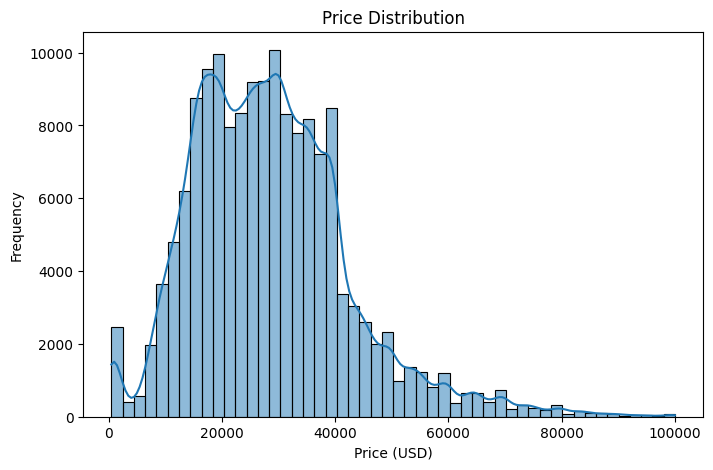

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde= True)
plt.title('Price Distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

## 🚗 Odometer (Mileage) Analysis

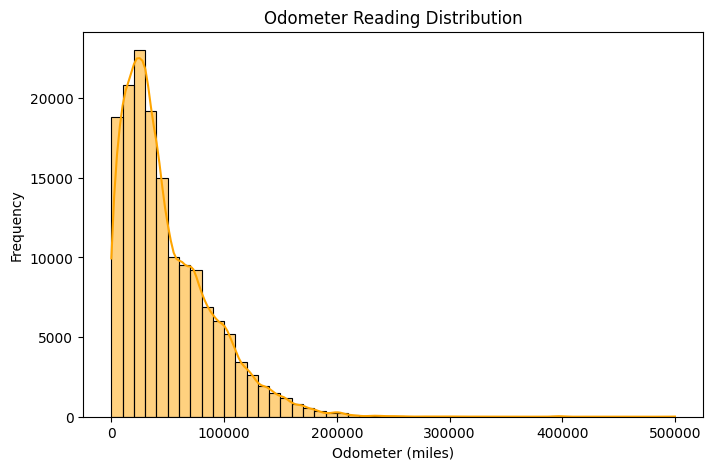

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['odometer'], bins=50, kde=True, color='orange')
plt.title('Odometer Reading Distribution')
plt.xlabel('Odometer (miles)')
plt.ylabel('Frequency')
plt.show()

## 🏷️ Price by Manufacturer (Top 10)

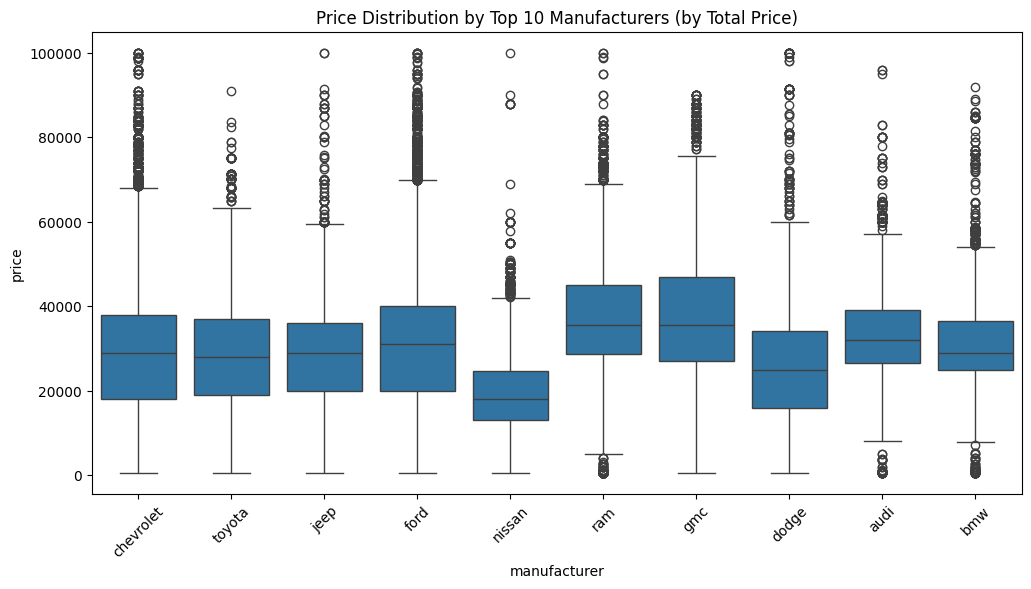

In [ ]:

top_brands = df.groupby('manufacturer')['price'].sum().nlargest(10).index

plt.figure(figsize=(12, 6))
sns.boxplot(x='manufacturer', y='price', data=df[df['manufacturer'].isin(top_brands)])
plt.title('Price Distribution by Top 10 Manufacturers (by Total Price)')
plt.xticks(rotation=45)
plt.show()


## 🛠️ Price by Vehicle Condition

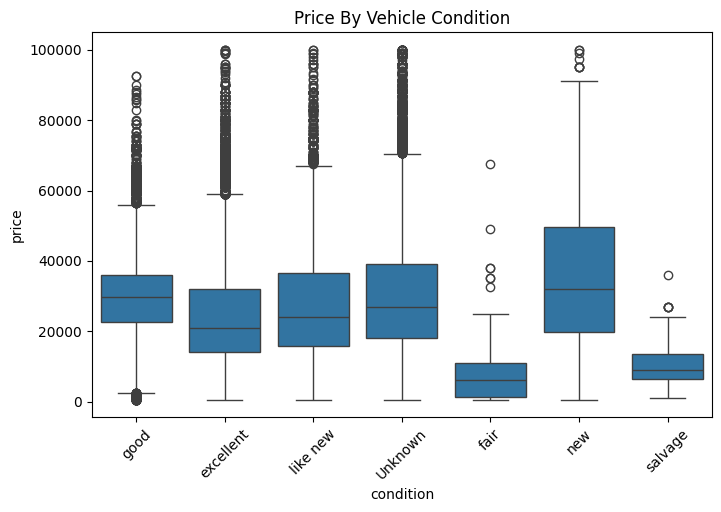

In [ ]:
plt.figure(figsize = (8,5))
sns.boxplot(x = 'condition', y = 'price', data = df)
plt.title('Price By Vehicle Condition')
plt.xticks(rotation = 45)
plt.show()

## 🔗 Feature Correlations

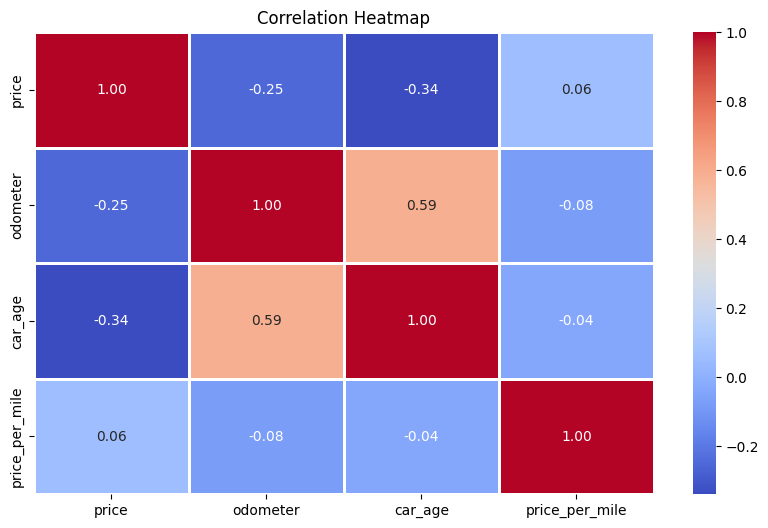

In [ ]:
plt.figure(figsize = (10,6))
sns.heatmap(df[['price', 'odometer', 'car_age', 'price_per_mile']].corr(),
            annot = True, cmap = 'coolwarm', linewidth = 1, fmt= '.2f')
plt.title("Correlation Heatmap")
plt.show()

## 🛢️ Grouped Insights

#####  Average Price by Fuel Type

In [ ]:
df.groupby('fuel')['price'].mean().sort_values(ascending = False)

,price
fuel,
diesel,49007.734343
other,31580.659940
electric,29211.127479
gas,26792.108023
Unknown,24775.709058
hybrid,23614.611927


##  **Count of Listings by State (Top 10)**


In [ ]:
df['state'].value_counts().head(10)

,count
state,
ca,16910
fl,10792
tx,10340
ny,7085
wa,6012
oh,5879
mi,5782
nc,5241
tn,5171


##  **Average Price by Transmission Type**

In [ ]:
df.groupby('transmission')['price'].mean().sort_values(ascending=False)

,price
transmission,
other,29861.485067
Unknown,29574.247261
automatic,28240.680685
manual,26418.667964


## Pairplot of Key Predictors

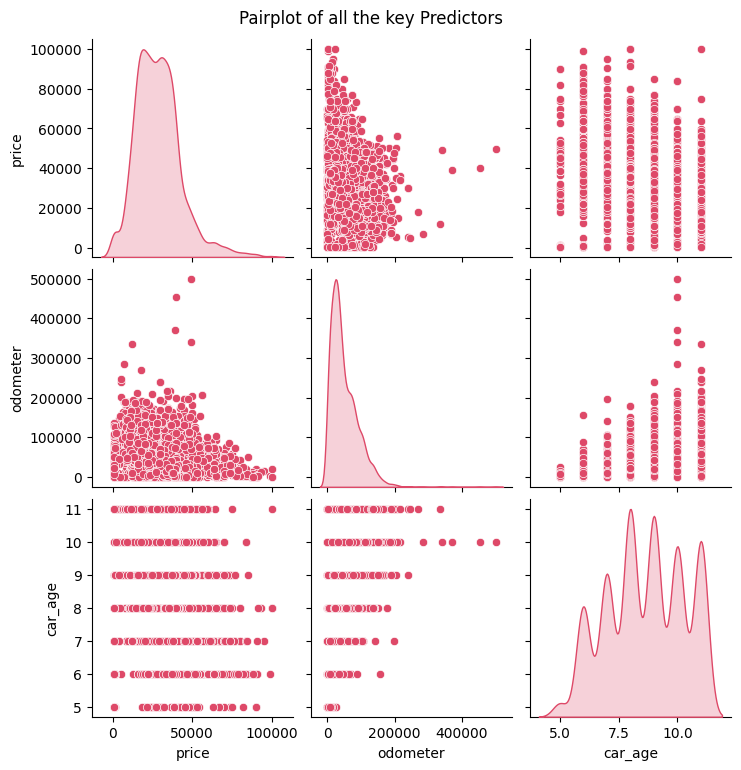

In [ ]:
sample_df = df.sample(5000, random_state=42)
magma_color = cm.magma(0.6)
sns.pairplot(
    sample_df[['price', 'odometer', 'car_age']],
    diag_kind='kde',
    plot_kws={'color': magma_color},
    diag_kws={'color': magma_color}
)
plt.suptitle('Pairplot of all the key Predictors', y=1.02)
plt.show()

### **🔧 Data Preprocessing Pipeline for Vehicle Price Prediction**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


df = pd.read_csv('/content/cleaned_vehicles111.csv')


df = df.drop(['id', 'region', 'model', 'description', 'image_url'], axis=1, errors='ignore')

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = ['manufacturer', 'condition', 'cylinders', 'fuel',
                    'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
numerical_cols = ['year', 'odometer', 'car_age', 'price_per_mile']

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (125431, 14)
Test set shape: (31358, 14)


## 📊 **Linear Regression Model Evaluation for Vehicle Price Prediction**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/cleaned_vehicles111.csv')

df = df.drop(['id', 'region', 'model', 'description', 'image_url'], axis=1, errors='ignore')

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(inplace=True)


X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = ['manufacturer', 'condition', 'cylinders', 'fuel',
                    'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
numerical_cols = ['year', 'odometer', 'car_age', 'price_per_mile']

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    model_pipeline.fit(X_train, y_train)

    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"Training MAE: {train_mae:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Training RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print(f"Training R2: {train_r2:.2f}")
    print(f"Test R2: {test_r2:.2f}")

    return model_pipeline, {
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2
    }

print("Linear Regression Results:")
lr_model, lr_metrics = evaluate_model(LinearRegression(), X_train, X_test, y_train, y_test)

Linear Regression Results:
Training MAE: 6053.10
Test MAE: 5998.79
Training RMSE: 8944.02
Test RMSE: 8873.47
Training R2: 0.60
Test R2: 0.59


## 🌲 **Random Forest Regressor for Vehicle Price Prediction**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=50,
                                max_depth=10,
                                random_state=42,
                                n_jobs=-1)

print("\nRandom Forest Results:")
rf_model, rf_metrics = evaluate_model(rf_model, X_train, X_test, y_train, y_test)


Random Forest Results:
Training MAE: 1720.41
Test MAE: 1764.04
Training RMSE: 3995.81
Test RMSE: 4179.07
Training R2: 0.92
Test R2: 0.91


In [ ]:
!pip install xgboost

## ⚡️ **XGBoost Regressor for Vehicle Price Prediction**

In [ ]:
from xgboost import XGBRegressor

print("\nXGBoost Results:")
xgb_model = XGBRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=10,
    eval_metric='mae',
    tree_method='hist'
)

preprocessor.fit(X_train)
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

xgb_model.fit(
    X_train_preprocessed,
    y_train,
    eval_set=[(X_test_preprocessed, y_test)],
    verbose=1
)

y_train_pred = xgb_model.predict(X_train_preprocessed)
y_test_pred = xgb_model.predict(X_test_preprocessed)


train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

xgb_metrics = {
    'train_mae': train_mae,
    'test_mae': test_mae,
    'train_rmse': train_rmse,
    'test_rmse': test_rmse,
    'train_r2': train_r2,
    'test_r2': test_r2
}

print(f"Training MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Training R2: {train_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")


XGBoost Results:
[0]	validation_0-mae:9838.38083
[1]	validation_0-mae:9070.77937
[2]	validation_0-mae:8476.08922
[3]	validation_0-mae:7871.85923
[4]	validation_0-mae:7504.11717
[5]	validation_0-mae:6997.57786
[6]	validation_0-mae:6507.44372
[7]	validation_0-mae:6243.00866
[8]	validation_0-mae:5843.95398
[9]	validation_0-mae:5647.91093
[10]	validation_0-mae:5250.54768
[11]	validation_0-mae:4887.63577
[12]	validation_0-mae:4747.79460
[13]	validation_0-mae:4430.06449
[14]	validation_0-mae:4268.45331
[15]	validation_0-mae:4001.16566
[16]	validation_0-mae:3773.83098
[17]	validation_0-mae:3570.40014
[18]	validation_0-mae:3373.11945
[19]	validation_0-mae:3243.04836
[20]	validation_0-mae:3087.72557
[21]	validation_0-mae:2935.91693
[22]	validation_0-mae:2902.78778
[23]	validation_0-mae:2784.69489
[24]	validation_0-mae:2682.77848
[25]	validation_0-mae:2579.52194
[26]	validation_0-mae:2478.15253
[27]	validation_0-mae:2431.29505
[28]	validation_0-mae:2390.95430
[29]	validation_0-mae:2356.96131
[3

## 📊 **Model Performance Comparison**

In [ ]:

metrics_df = pd.DataFrame({
    'Linear Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}).T

print("\nModel Comparison:")
metrics_df


Model Comparison:


,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
Linear Regression,6053.104587,5998.787421,8944.021323,8873.472271,0.597951,0.593762
Random Forest,1720.408070,1764.039716,3995.807613,4179.073756,0.919754,0.909894
XGBoost,826.647156,862.520691,1453.227959,1700.137936,0.989386,0.985087


## 🔍 **Top 20 Feature Importances – XGBoost**

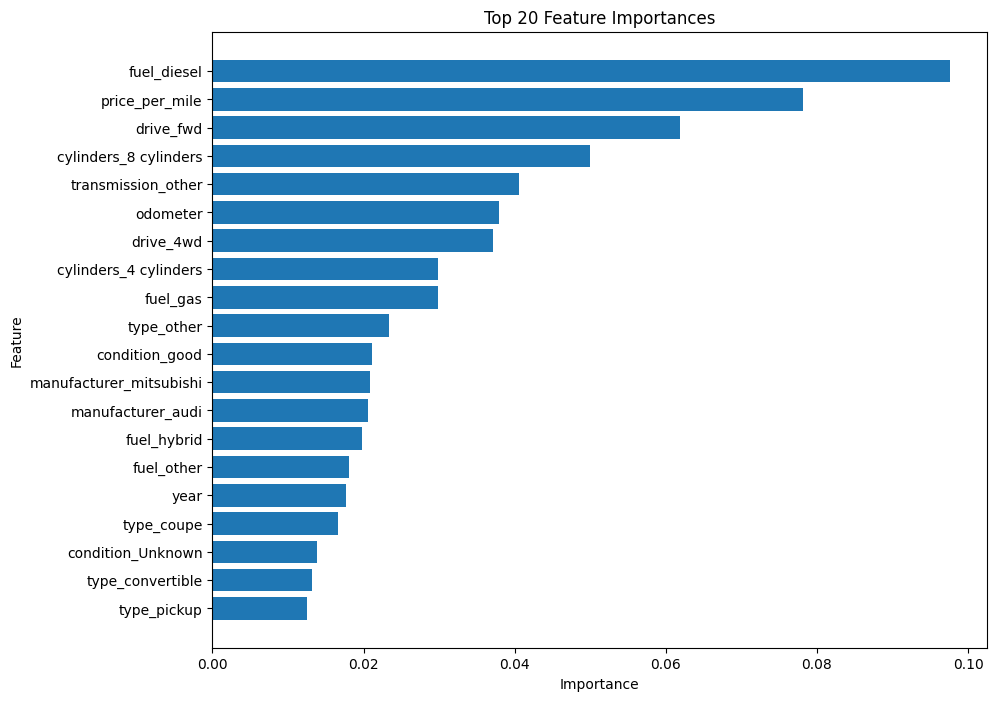

In [ ]:
import matplotlib.pyplot as plt

preprocessor.fit(X_train)
feature_names = (numerical_cols +
                 list(preprocessor.named_transformers_['cat']
                     .get_feature_names_out(categorical_cols)))

importances = xgb_model.feature_importances_


feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)


plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

## 🎯 **Hyperparameter Tuning – XGBoost with GridSearchCV**

In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.1, 0.2]
}


xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])


grid_search = GridSearchCV(xgb_pipeline, param_grid, cv=3,
                          scoring='neg_mean_absolute_error',
                          n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)


best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)

print("\nTuned XGBoost Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.2f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'model__learning_rate': 0.2, 'model__max_depth': 9, 'model__n_estimators': 150}

Tuned XGBoost Performance:
MAE: 381.62
RMSE: 1281.21
R2: 0.99


## **Actual vs Predicted Car Prices using Tuned XGBoost Model**


Sample Predictions:
        Actual     Predicted  Difference  Pct_Difference
95022    33590  33797.507812 -207.507812       -0.617767
149509   36999  37395.457031 -396.457031       -1.071534
119414   38590  38504.527344   85.472656        0.221489
65449    29500  29370.955078  129.044922        0.437440
134615   24990  25008.050781  -18.050781       -0.072232
148360   22999  22767.931641  231.068359        1.004689
62808    24460  24374.546875   85.453125        0.349359
18607    29990  29949.041016   40.958984        0.136575
62284    35990  36353.218750 -363.218750       -1.009221
99757    13500  13570.687500  -70.687500       -0.523611


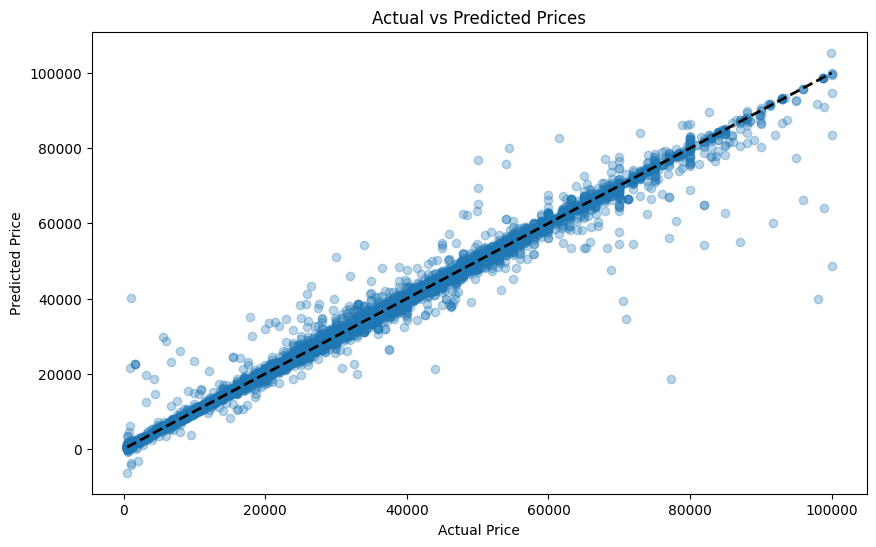

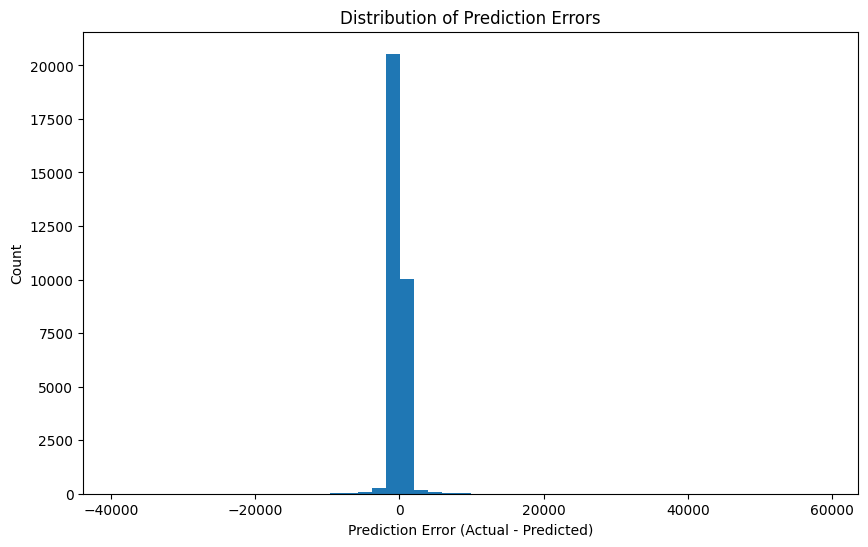

In [ ]:

final_predictions = best_xgb.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': final_predictions,
    'Difference': y_test - final_predictions
})

results['Pct_Difference'] = (results['Difference'] / results['Actual']) * 100

print("\nSample Predictions:")
print(results.sample(10))

plt.figure(figsize=(10, 6))
plt.scatter(y_test, final_predictions, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results['Difference'], bins=50)
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.show()

In [ ]:
import joblib

joblib.dump(best_xgb, 'car_price_predictor.pkl')


['car_price_predictor.pkl']